In [10]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [11]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [12]:
query = """
CREATE TABLE datamart AS
SELECT checker.uid AS uid, labname, timestamp AS first_commit_ts, first_view_ts
FROM
    checker
    LEFT JOIN (
        SELECT uid, MIN(datetime) AS first_view_ts
        FROM pageviews
        GROUP BY uid
    ) first_views
    ON checker.uid = first_views.uid
WHERE status = 'ready' AND numTrials = 1 AND labname IN ('laba04', 'laba04s', 'laba05', 'laba06', 'laba06s', 'project1') AND checker.uid LIKE 'user_%'

"""
conn.execute('DROP TABLE IF EXISTS datamart;')
conn.execute(query)
query_datamart = """
SELECT *
FROM datamart
"""

datamart = pd.io.sql.read_sql(query_datamart, conn, parse_dates=['first_commit_ts', 'first_view_ts'])
datamart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   uid              140 non-null    object        
 1   labname          140 non-null    object        
 2   first_commit_ts  140 non-null    datetime64[ns]
 3   first_view_ts    59 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 4.5+ KB


In [13]:
test_users = datamart.groupby('uid').first_view_ts.count()
test_users = test_users.loc[test_users > 0]
test = datamart.loc[datamart.uid.isin(test_users.index)]
test.to_sql('test', conn, if_exists='replace')

59

In [14]:
query = """
SELECT test.uid, AVG((strftime("%s", first_commit_ts) - deadlines)/3600) AS avg_diff, pageviews, num_commits
FROM
    deadlines
    INNER JOIN test ON labname = labs AND labname <> "project1"
    INNER JOIN
    (
    SELECT uid, COUNT(datetime) AS pageviews
    FROM
        pageviews
    GROUP BY uid
    ) pageviews_count
    ON test.uid = pageviews_count.uid
    INNER JOIN 
    (
        SELECT COUNT(*) AS num_commits, uid
        FROM
            checker
        WHERE labname <> "project1"
        GROUP BY uid
    ) num_commits_query
    ON test.uid = num_commits_query.uid

GROUP BY test.uid, pageviews;
"""
scatter_df = pd.io.sql.read_sql(query, conn)
len(scatter_df)

11

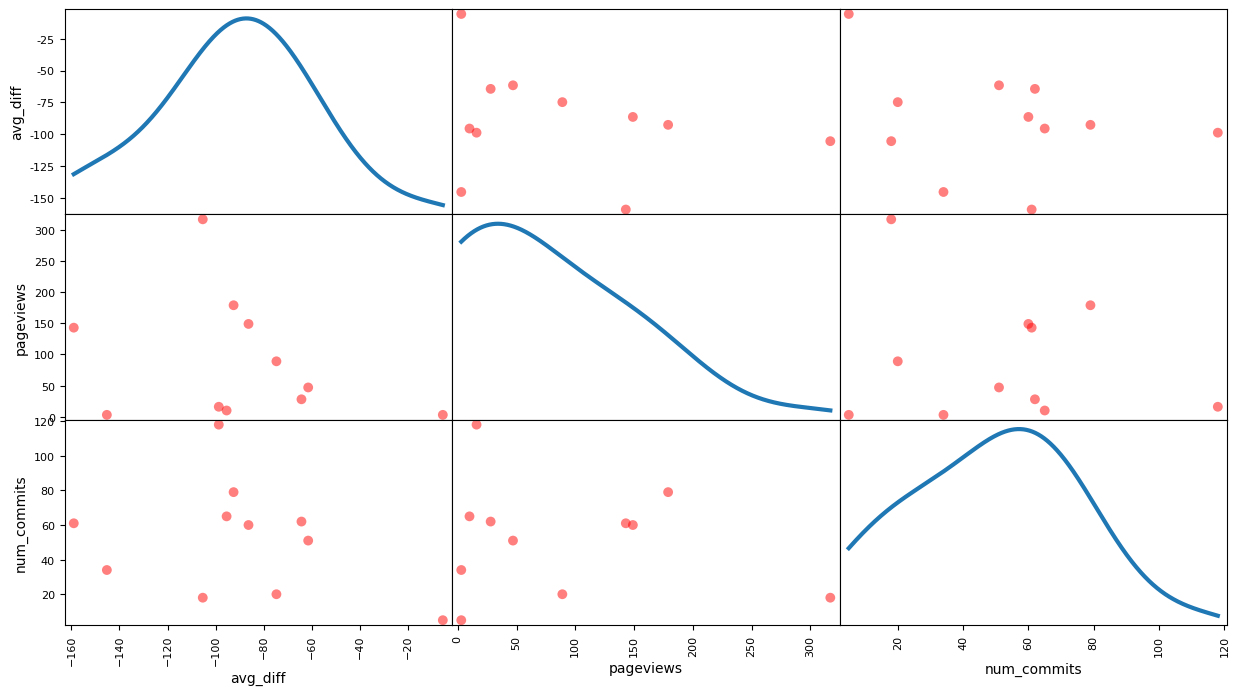

In [6]:
graphs = scatter_matrix(scatter_df, s=200, c='r', figsize=(15, 8), diagonal='kde', linewidth=3)
for i in range(3):
    graphs[i][i].lines[0].set_linewidth(3)

In [7]:
conn.close()

*answer: no*

*answer: no*

*answer: yes*

*answer: no*